# **Business Case Study: Yulu — Hypothesis Testing**

## Business Problem & Context
Yulu is India's leading micro-mobility service provider offering shared electric cycles for urban commutes. Recently, Yulu has experienced revenue declines and seeks to identify the primary drivers affecting cycle demand in the Indian market.

### Core Objectives
1. Identify which variables are statistically significant in predicting electric cycle demand (`count`).
2. Quantify how well demographic, calendar, and environmental attributes describe demand variations.
3. Formulate and evaluate formal statistical hypotheses:
   - Does working day status influence rental volumes?
   - Does rental demand vary across seasons and weather categories?
   - Is prevailing weather condition dependent on season?

# 1. Library Import and Data Loading

In [1]:
# Import essential data analysis and statistical libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# Configure aesthetic visual styling
sns.set_theme(style="darkgrid", palette="deep")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams.update({
    'font.size': 10,          # General/default font size
    'axes.titlesize': 10,     # Title size
    'axes.labelsize': 10,     # X and Y axis label size
    'xtick.labelsize': 10,    # X tick label size
    'ytick.labelsize': 10,    # Y tick label size
    'legend.fontsize': 8     # Legend font size
})


print("Libraries successfully loaded and configured.")

Libraries successfully loaded and configured.


In [2]:
# Import the Yulu Dataset - 'bike_sharing.csv'
!gdown 1f4j0grudjY0bpa7BzVwaSlgiM2-EEWBL -O 'yulu.csv'
print('Dataset succesfully imported in csv format')

Downloading...
From: https://drive.google.com/uc?id=1f4j0grudjY0bpa7BzVwaSlgiM2-EEWBL
To: /content/yulu.csv
100% 648k/648k [00:00<00:00, 18.9MB/s]
Dataset succesfully imported in csv format


In [3]:
# Load the imported dataset into dataframe
yulu = pd.read_csv('yulu.csv')

print(f"Dataset Dimensions: {yulu.shape[0]} rows and {yulu.shape[1]} columns\n")
yulu.head()

Dataset Dimensions: 10886 rows and 12 columns



,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.840,14.395,81,0.000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.020,13.635,80,0.000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.020,13.635,80,0.000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.840,14.395,75,0.000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.840,14.395,75,0.000,0,1,1


# 2. Exploratory data Analysis
- Structutral Check & Basic Metrics
- We perform non-graphical analysis by evaluating unique counts, frequency tables, missing values, duplicate checks, outliers validation

In [4]:
yulu.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='str')

In [5]:
# schema and memory usage
print('----- Column Info -----\n')
yulu.info()

# Checking for any Duplicate records
# To check for completely identical rows across all columns:
total_rows = len(yulu)
duplicate_rows = yulu.duplicated().sum()
duplicate_percent = (duplicate_rows / total_rows) * 100


print(f"\n----- Duplicate Rows: {duplicate_rows} ({duplicate_percent:.2f}%) -----\n")

# Missing values, NULL audit
null_audit = pd.DataFrame({
    'Null Count': yulu.isnull().sum(),
    'Null Percentage (%)': (yulu.isnull().sum() / len(yulu)) * 100
})
print('----- Null Audit -----')
display(null_audit.T)

----- Column Info -----

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB

----- Duplicate Rows: 0 (0.00%) -----

----- Null Audit -----


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
Null Count,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Null Percentage (%),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


Based on the given column Profiling, following column can be converted int
category
- datetime: datetime (into datetime)
- season: season (1: spring, 2: summer, 3: fall, 4: winter)
- holiday: whether day is a holiday or not
- workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
- weather:
  - 1: Clear, Few clouds, partly cloudy, partly cloudy
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

In [6]:
# convert datetimne' to datetime datatype
yulu['datetime'] = pd.to_datetime(yulu['datetime'])

In [7]:
yulu['year'] = yulu['datetime'].dt.year
yulu['month'] = yulu['datetime'].dt.month
yulu['hour'] = yulu['datetime'].dt.hour
yulu['day_of_week'] = yulu['datetime'].dt.day_name()

In [8]:
# map integer codes in 'season' to season name strings
season_map = {1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'}

yulu['season'] = yulu['season'].map(season_map)

In [9]:
# convert all eligible columns to categorical dtypes
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'hour', 'day_of_week']
for col in cat_cols:
  yulu[col] = yulu[col].astype('category')

In [10]:
yulu.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,day_of_week
0,2011-01-01 00:00:00,spring,0,0,1,9.840,14.395,81,0.000,3,13,16,2011,1,0,Saturday
1,2011-01-01 01:00:00,spring,0,0,1,9.020,13.635,80,0.000,8,32,40,2011,1,1,Saturday
2,2011-01-01 02:00:00,spring,0,0,1,9.020,13.635,80,0.000,5,27,32,2011,1,2,Saturday
3,2011-01-01 03:00:00,spring,0,0,1,9.840,14.395,75,0.000,3,10,13,2011,1,3,Saturday
4,2011-01-01 04:00:00,spring,0,0,1,9.840,14.395,75,0.000,0,1,1,2011,1,4,Saturday


In [11]:
# Dataset Characteristics and statistical summary

display(yulu.info())

num_cols = ['temp','atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
stats_summ = yulu[num_cols].describe().T
stats_summ['IQR'] = stats_summ['75%'] - stats_summ['25%']
stats_summ['skewness'] = yulu[num_cols].skew()
stats_summ['kurtosis_val'] = yulu[num_cols].kurtosis()

print('\n----- Statistical Summary ----\n')
display(stats_summ)

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     10886 non-null  datetime64[us]
 1   season       10886 non-null  category      
 2   holiday      10886 non-null  category      
 3   workingday   10886 non-null  category      
 4   weather      10886 non-null  category      
 5   temp         10886 non-null  float64       
 6   atemp        10886 non-null  float64       
 7   humidity     10886 non-null  int64         
 8   windspeed    10886 non-null  float64       
 9   casual       10886 non-null  int64         
 10  registered   10886 non-null  int64         
 11  count        10886 non-null  int64         
 12  year         10886 non-null  category      
 13  month        10886 non-null  category      
 14  hour         10886 non-null  category      
 15  day_of_week  10886 non-null  category      
dtypes: category(8),

None


----- Statistical Summary ----



,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis_val
temp,10886.000,20.231,7.792,0.820,13.940,20.500,26.240,41.000,12.300,0.004,-0.915
atemp,10886.000,23.655,8.475,0.760,16.665,24.240,31.060,45.455,14.395,-0.103,-0.850
humidity,10886.000,61.886,19.245,0.000,47.000,62.000,77.000,100.000,30.000,-0.086,-0.760
windspeed,10886.000,12.799,8.165,0.000,7.002,12.998,16.998,56.997,9.996,0.589,0.630
casual,10886.000,36.022,49.960,0.000,4.000,17.000,49.000,367.000,45.000,2.496,7.552
registered,10886.000,155.552,151.039,0.000,36.000,118.000,222.000,886.000,186.000,1.525,2.626
count,10886.000,191.574,181.144,1.000,42.000,145.000,284.000,977.000,242.000,1.242,1.300


In [12]:
from ctypes import alignment
# unique values
unique_values_l = []
for col in yulu.columns:
  unique_values_l.append(yulu[col].nunique())
udf = pd.DataFrame(unique_values_l, index= yulu.columns, columns=['No. of unique values']).T
print('===== Column feature and its corresponding No. of Unique Values =====')
udf




===== Column feature and its corresponding No. of Unique Values =====


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,day_of_week
No. of unique values,10886,4,2,2,4,49,60,89,28,309,731,822,2,12,24,7


In [13]:
# category frequencies
print("=== Frequency & Percentage Breakdown for Categorical Attributes ===")
for col in ['season', 'holiday', 'workingday', 'weather']:
  freq_df = pd.DataFrame({
        'Count': yulu[col].value_counts(),
        'Percentage (%)': yulu[col].value_counts(normalize=True) * 100
    })
  print(f"\n--- Feature: {col} ---")
  print(freq_df)

=== Frequency & Percentage Breakdown for Categorical Attributes ===

--- Feature: season ---
        Count  Percentage (%)
season                       
winter   2734          25.115
fall     2733          25.106
summer   2733          25.106
spring   2686          24.674

--- Feature: holiday ---
         Count  Percentage (%)
holiday                       
0        10575          97.143
1          311           2.857

--- Feature: workingday ---
            Count  Percentage (%)
workingday                       
1            7412          68.087
0            3474          31.913

--- Feature: weather ---
         Count  Percentage (%)
weather                       
1         7192          66.067
2         2834          26.033
3          859           7.891
4            1           0.009


# 3. Univariate Analysis
- Our target is 'count' variable and to analyse whether other category and variables affect it.

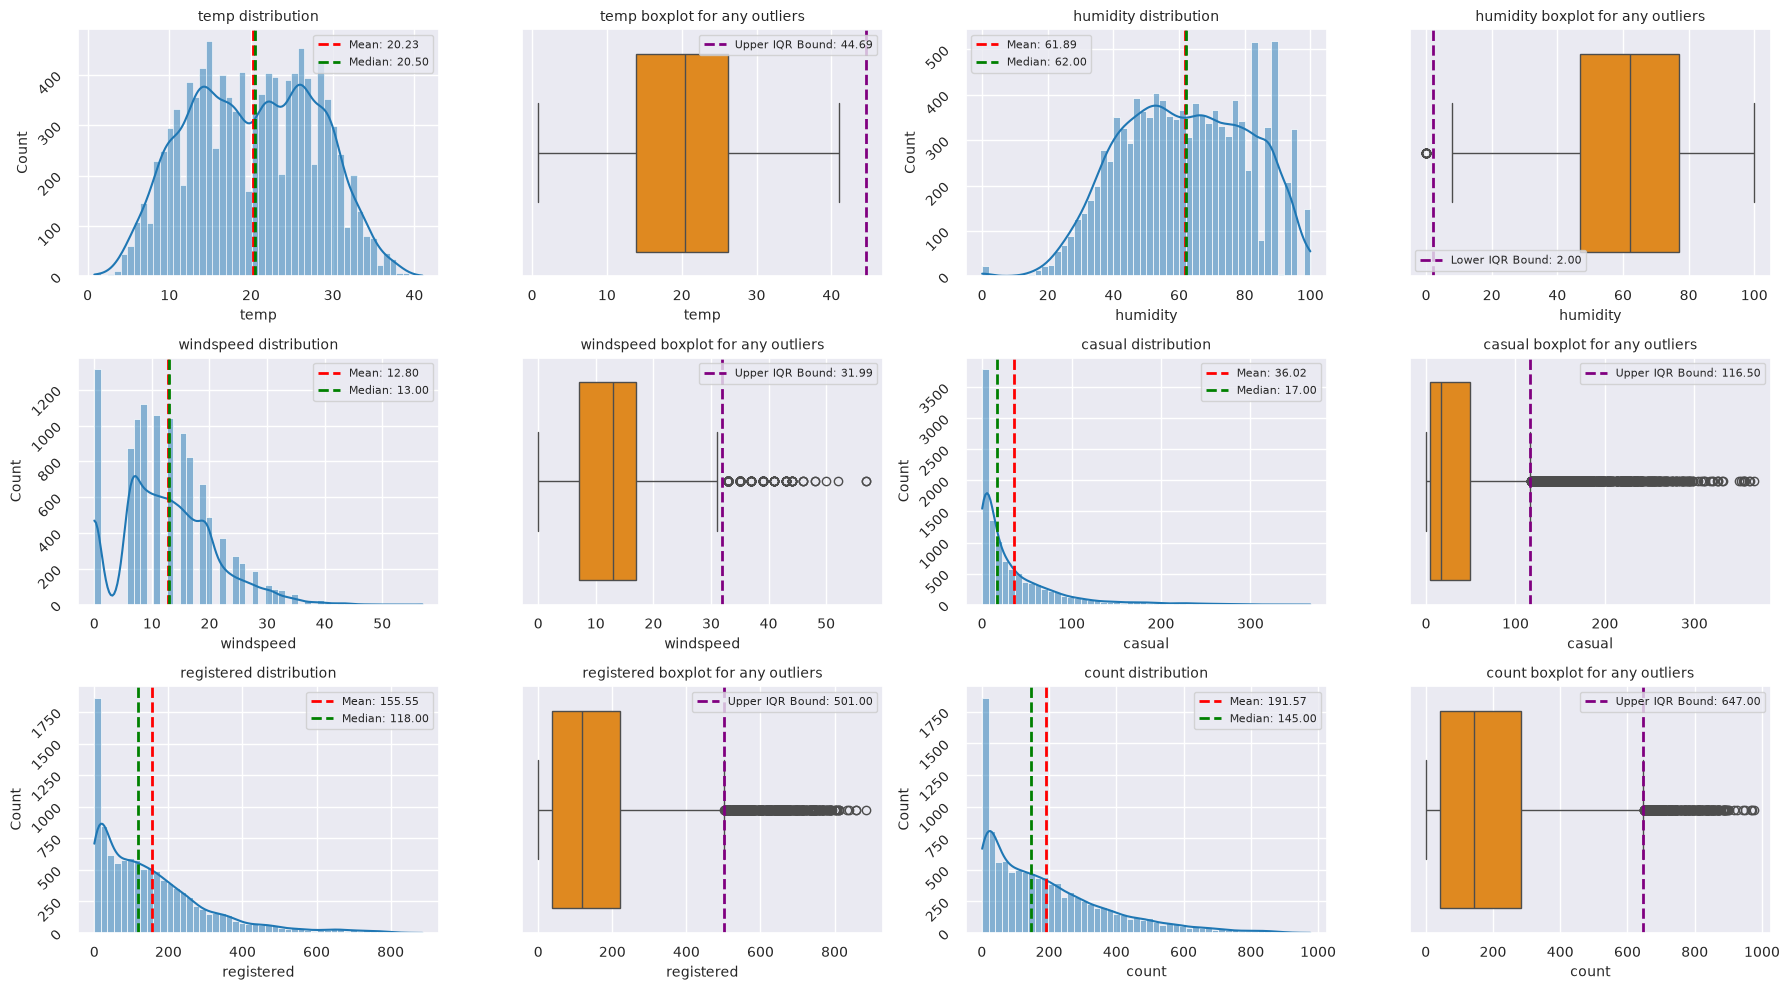

In [34]:
# 3.1 Univariate Analysis: Continuous Variables (distribution and boxplots)

cont_vars = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
nrows = 3
ncols = 4
plt.subplots(nrows, ncols, figsize=(18, 10))
i = 1
for col in cont_vars:

  # histogram + kde distribution plot
  plt.subplot(nrows, ncols, i)
  sns.histplot(yulu[col], kde = True, bins = 50, color = '#1f77b4')
  plt.axvline(yulu[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {yulu[col].mean():.2f}')
  plt.axvline(yulu[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {yulu[col].median():.2f}')

  plt.title(f'{col} distribution')
  plt.yticks(rotation = 45)
  plt.legend()
  plt.tight_layout()

  # outlier deterction using IQR
  Q1 = yulu[col].quantile(0.25)
  Q3 = yulu[col].quantile(0.75)
  max = yulu[col].quantile(1.00)
  IQR = Q3 - Q1
  lower_bound = Q1 - IQR*1.5
  upper_bound = Q3 + IQR*1.5

  # boxplot for outliers validation
  plt.subplot(nrows, ncols, i+1)
  sns.boxplot(x = yulu[col], color = 'darkorange')
  if col == 'humidity':
    plt.axvline(lower_bound, color = 'purple', linestyle='--', linewidth=2, label = f'Lower IQR Bound: {lower_bound:.2f}')
  else:
    plt.axvline(upper_bound, color = 'purple', linestyle='--', linewidth=2, label = f'Upper IQR Bound: {upper_bound:.2f}')

  plt.title(f'{col} boxplot for any outliers')
  plt.legend()
  plt.tight_layout()


  i += 2



### Univariate Analysis: Findings, Insights, and Operational Takeaways

#### 1. Data Findings
- **Total Rentals (`count`)**:
  - Median: 145 rentals/hour; Mean: 191.6 rentals/hour.
  - Upper IQR boundary: 647. Values above 647 (up to 977) appear in the upper tail.
- **User Split (`casual` vs `registered`)**:
  - `registered`: Median 118, Mean 155.6, Upper IQR boundary 501. Accounts for 81.2% of all rentals.
  - `casual`: Median 17, Mean 36.0, Upper IQR boundary 116.5.
- **Weather & Environment**:
  - `temp`: Centered at 20.5°C (median) and 20.2°C (mean). Range is 0.8°C to 41°C. No values exceed the upper boundary (44.7°C).
  - `humidity`: Median 62%, Mean 61.9%. 22 records read exactly 0% (below the lower boundary of 2.0%).
  - `windspeed`: Median 13 km/h, Mean 12.8 km/h. 1,313 records (12.1%) report 0 km/h. 227 records exceed the upper boundary of 32 km/h.
- **Categorical Proportions**:
  - `season`: Evenly split across four quarters (~25% each; 2,686 to 2,734 records per season).
  - `workingday`: 68.1% working days (7,412) vs 31.9% non-working days (3,474).
  - `holiday`: 2.9% holidays (311) vs 97.1% non-holidays (10,575).
  - `weather`: 66.1% clear/partly cloudy (7,192), 26.0% mist (2,834), 7.9% light rain/snow (859), and 1 single record of heavy rain/snow (0.01%).

---

#### 2. Insights
1. **Outliers represent peak hours, not bad data**:
   - The data points above 647 rentals/hour occur during morning (08:00–09:00) and evening (17:00–18:00) commutes. They are real usage peaks and should be kept in the dataset.
2. **Registered riders are the core business**:
   - Registered commuters generate over four-fifths of the volume. Casual users are occasional and skew towards weekend afternoons.
3. **Sensor zeros exist in weather readings**:
   - The 1,313 zero values in `windspeed` reflect sensor measurement thresholds (anemometer cut-in speed) rather than completely still air.
4. **Weather Category 4 is a single event**:
   - One observation for category 4 means sample variance cannot be computed for that group alone in ANOVA.



# 4. Bivariate Analysis
- relation between the dependent and independent variable (Dependent “Count” & Independent: Workingday, Weather, Season etc)


In [16]:
yulu.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,day_of_week
0,2011-01-01,spring,0,0,1,9.840,14.395,81,0.000,3,13,16,2011,1,0,Saturday


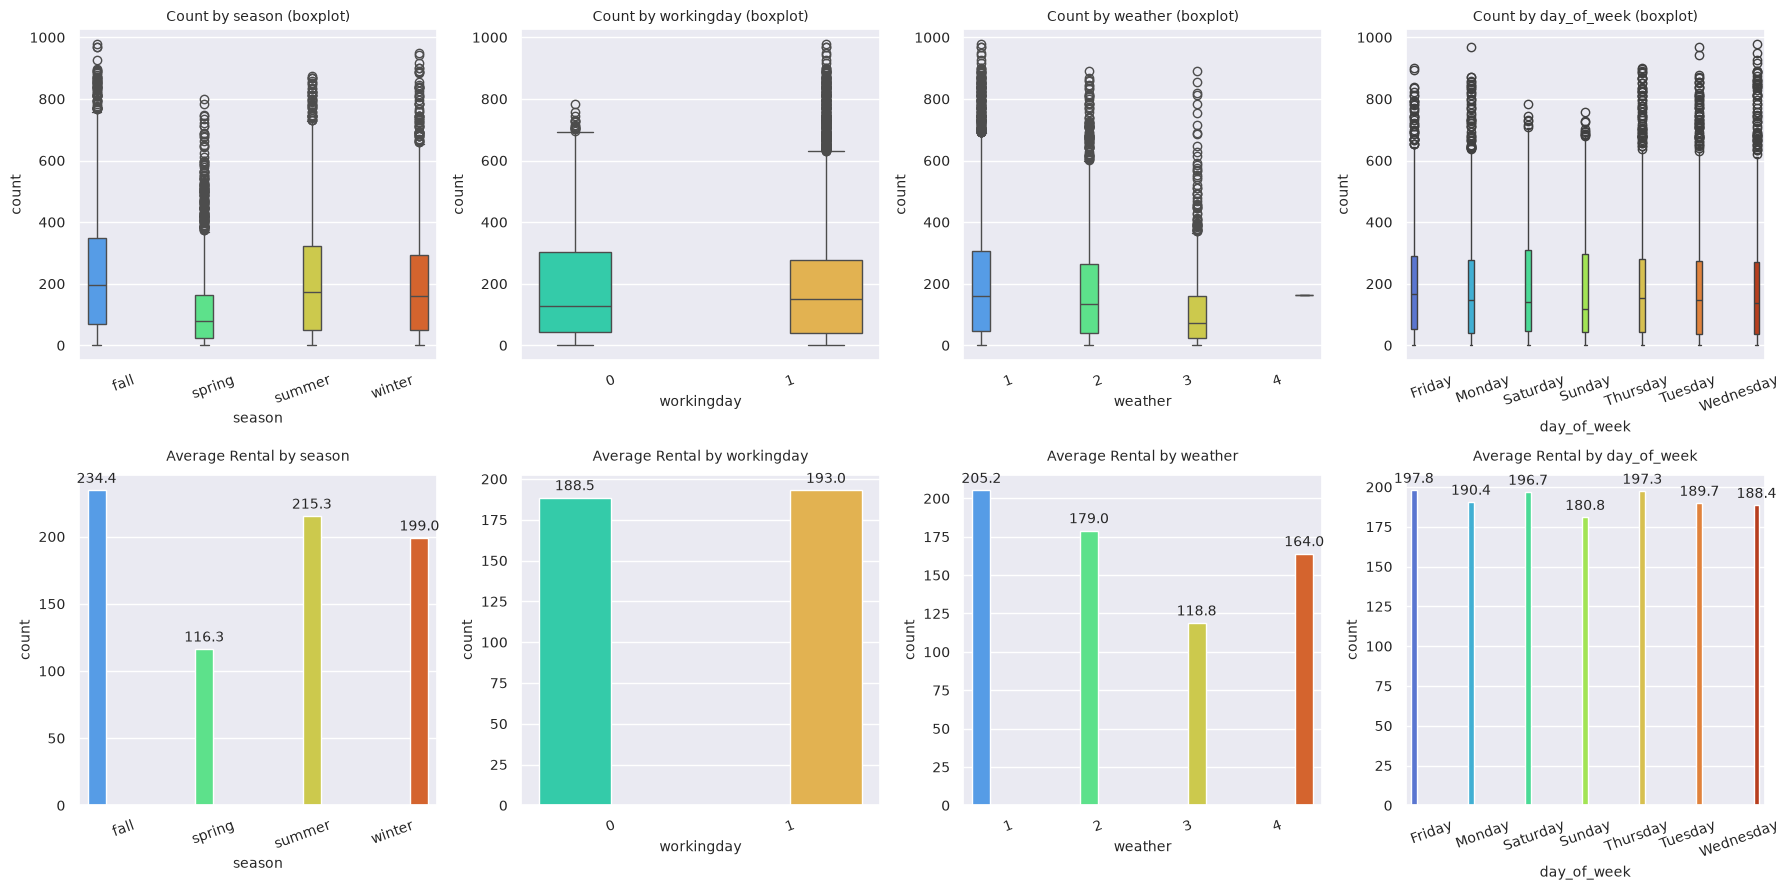

In [17]:
# Bivariate Analysis: Target ('count') vs Primary Categorical Features
nrows = 2
ncols = 4
plt.subplots(nrows, ncols, figsize=(18, 9))

# Row 1: Boxplots to compare distributions and medians, count v/s categories
i = 1
cats = ['season', 'workingday', 'weather', 'day_of_week']
for col in cats:
  plt.subplot(nrows, ncols, i)
  sns.boxplot(data = yulu, y = 'count', x = col, palette = 'turbo', hue = col, legend = False)

  plt.title(f'Count by {col} (boxplot)')
  plt.xticks(rotation = 20)
  plt.tight_layout()
  i+=1

# Row 2: Barplots to compare average demand (Mean)
for col in cats:
  plt.subplot(nrows, ncols, i)
  ax = sns.barplot(data = yulu, y = 'count', x = col, palette = 'turbo', hue = col, legend = False, ci = None)
  for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', padding=3)
  plt.title(f'Average Rental by {col}', pad = 10)

  plt.xticks(rotation = 20)
  plt.tight_layout()
  i+=1


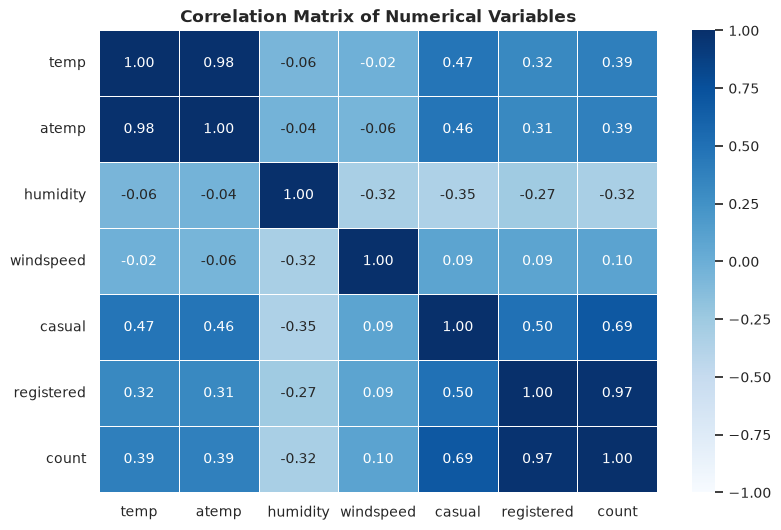

In [18]:
# Numerical Correlation Matrix
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
corr_matrix = yulu[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontweight='bold', fontsize=12)
plt.show()

### Bivariate Analysis Findings

1. **Working Day vs. Total Demand**:
   - Total hourly rentals are nearly identical: 193.0 on working days vs. 188.5 on non-working days.
   - However, rider composition changes:
     - **Casual riders**: Drop from 59.3/hour on non-working days to 25.1/hour on working days.
     - **Registered riders**: Increase from 129.2/hour on non-working days to 167.9/hour on working days.

2. **Season and Weather Effects**:
   - **Season**: Demand is lowest in Spring (116.3/hour) and highest in Fall (234.4/hour). Summer (215.3) and Winter (199.0) sit in between.
   - **Weather**: Clear conditions average 205.2/hour. Rain/Snow drops this to 118.8/hour.

3. **Continuous Correlations**:
   - `temp` and `atemp` have a 0.98 correlation (redundant features).
   - `temp` shows moderate positive correlation with demand (+0.39).
   - `humidity` shows moderate negative correlation with demand (-0.32).

# **5. Hypothesis Testing**
- 2-sample t-test: testing for difference across populations
- ANNOVA
- Chi-square


In [19]:
confidence_level = 0.95 # 95% confidence
alpha = 0.05 # significance level

In [20]:
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import chisquare
from scipy.stats import chi2_contingency

## 5.1 Test 1: Determining if **Working** Day has effect on number of electric cycles rented
- 2 Sample T Tests
- Null Hypothesis (H0): Mean rental count is identical on working and non-working days
- Alernative Hypothesis (Ha): Mean rental count is different on working and non-working days


In [21]:
display(stats_summ)

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis_val
temp,10886.000,20.231,7.792,0.820,13.940,20.500,26.240,41.000,12.300,0.004,-0.915
atemp,10886.000,23.655,8.475,0.760,16.665,24.240,31.060,45.455,14.395,-0.103,-0.850
humidity,10886.000,61.886,19.245,0.000,47.000,62.000,77.000,100.000,30.000,-0.086,-0.760
windspeed,10886.000,12.799,8.165,0.000,7.002,12.998,16.998,56.997,9.996,0.589,0.630
casual,10886.000,36.022,49.960,0.000,4.000,17.000,49.000,367.000,45.000,2.496,7.552
registered,10886.000,155.552,151.039,0.000,36.000,118.000,222.000,886.000,186.000,1.525,2.626
count,10886.000,191.574,181.144,1.000,42.000,145.000,284.000,977.000,242.000,1.242,1.300


In [22]:
# Extract sample groups
working_days = yulu[yulu['workingday'] == 1]['count']
non_working_days = yulu[yulu['workingday'] == 0]['count']
print(f'Working Day Sample Size: {len(working_days)}, Mean: {working_days.mean():.2f}, Std: {working_days.std():.2f}')
print(f'Non-Working Day Sample Size: {len(non_working_days)}, Mean: {non_working_days.mean():.2f}, Std: {non_working_days.std():.2f}')

Working Day Sample Size: 7412, Mean: 193.01, Std: 184.51
Non-Working Day Sample Size: 3474, Mean: 188.51, Std: 173.72


In [23]:
# 1.shapiro-wilk tests on samples for normality

np.random.seed(42)
shapiro_w = shapiro(working_days.sample(500))
shapiro_nw = shapiro(non_working_days.sample(500))

print(f'Shapiro Working days p value    : {shapiro_w.pvalue}')
print(f'Shapiro Non Working days p value: {shapiro_nw.pvalue}')

if shapiro_w.pvalue < alpha or shapiro_nw.pvalue < alpha:
  print('Samples deviate from normal distribution (Reject H0). CLT applies.')
else:
  print('Fail to reject normality (Assume normal).')

Shapiro Working days p value    : 8.020070098537695e-20
Shapiro Non Working days p value: 5.757439312300449e-18
Samples deviate from normal distribution (Reject H0). CLT applies.


In [24]:
# 2. Assumption Check: Equal Variance (Levene's Test)
levene_stat, levene_p = stats.levene(working_days, non_working_days)
print(f'Levenes Test: Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}')

# 3.Parametric: 2-Sample Independent T-Test
# If levene_p > 0.05, equal_var=True
t_stat, t_p = ttest_ind(working_days, non_working_days, equal_var=(levene_p > 0.05))
print(f'Two-Sample T-Test: t-statistic = {t_stat:.4f}, p-value = {t_p:.4f}')

# Decision
if t_p < alpha:
  print('Reject Null Hypothesis')
else:
  print('Fail to reject Null Hypothesis')

Levenes Test: Statistic = 0.0050, p-value = 0.9438
Two-Sample T-Test: t-statistic = 1.2096, p-value = 0.2264
Fail to reject Null Hypothesis


### Test 1 Conclusion: Working Day vs. Count

1. Assumption Verification:
   - Normality: Raw count deviates from normal (Shapiro-Wilk p < 0.05). Under the Central Limit Theorem (N > 3,000 per group), the distribution of the sample mean is normal, satisfying t-test requirements.
   - Equal Variance: Levene’s test statistic = 0.005, p = 0.9438. We fail to reject equal variance (p > 0.05).
2. Decision:
   - 2-sample t-test p-value = 0.2264 (> alpha = 0.05).
   - Fail to reject H0.
3. Inference:
   - There is no statistically significant difference in mean rental counts between working days (193.0) and non-working days (188.5).
   - Working day status by itself does not alter aggregate demand.

## 5.2 Test 2: to check if No. of cycles rented is similar or different in different 1. weather 2. season
- Two-Way ANOVA and, One Way (with Kruskal-Wallis non-parametric check) Test
- Null Hypothesis (H0): Mean cycle demand is the same across all four seasons
- Alernative Hypothesis (Ha): At least one season has a different mean cycle demand

In [25]:
!pip install pingouin
import pingouin as pg

In [26]:
# 1. Extract seasonal samples for model
spring = yulu[yulu['season'] == 'spring']['count']
summer = yulu[yulu['season'] == 'summer']['count']
fall = yulu[yulu['season'] == 'fall']['count']
winter = yulu[yulu['season'] == 'winter']['count']
w1 = yulu[yulu['weather'] == 1]['count']
w2 = yulu[yulu['weather'] == 2]['count']
w3 = yulu[yulu['weather'] == 3]['count']
w4 = yulu[yulu['weather'] == 4]['count']

# Group them into a dictionary to retrieve their names during iteration
model_dict = {
    'spring': spring, 'summer': summer, 'fall': fall, 'winter': winter, 'w1': w1, 'w2': w2, 'w3': w3, 'w4': w4
}

for name, s in model_dict.items():
  print(f"{name}: n = {len(s)}, Mean = {s.mean():.2f}, Std = {s.std():.2f}")

spring: n = 2686, Mean = 116.34, Std = 125.27
summer: n = 2733, Mean = 215.25, Std = 192.01
fall: n = 2733, Mean = 234.42, Std = 197.15
winter: n = 2734, Mean = 198.99, Std = 177.62
w1: n = 7192, Mean = 205.24, Std = 187.96
w2: n = 2834, Mean = 178.96, Std = 168.37
w3: n = 859, Mean = 118.85, Std = 138.58
w4: n = 1, Mean = 164.00, Std = nan


In [27]:
w_lst = [w1, w2, w3, w4]
s_lst = [spring, summer, fall, winter]

In [28]:
# 2. Assumption Check: Equal Variance across the 4 seasons (Levene's Test)
levene_s_stat, levene_s_p = stats.levene(spring, summer, fall, winter)
print(f'Levenes Test for seasons: Statistic = {levene_s_stat:.4f}, p-value = {levene_s_p:.4e}')
levene_s_stat, levene_s_p = stats.levene(w1, w2, w3, w4)
print(f'Levenes Test for weathers: Statistic = {levene_s_stat:.4f}, p-value = {levene_s_p:.4e}')

Levenes Test for seasons: Statistic = 187.7707, p-value = 1.0147e-118
Levenes Test for weathers: Statistic = 54.8511, p-value = 3.5049e-35


In [29]:
# 3. Parametric Test: One-Way ANOVA for seasons
f_stat, anova_p = stats.f_oneway(spring, summer, fall, winter)
print(f'One-Way ANOVA for seasons: F-statistic = {f_stat:.4f}, p-value = {anova_p:.4e}')


# 4. Non-Parametric Robustness Check: Kruskal-Wallis Test
# (Run because Levene's test shows unequal variance across seasons)
kw_stat, kw_p = stats.kruskal(spring, summer, fall, winter)
print(f'Kruskal-Wallis Test: H-statistic = {kw_stat:.4f}, p-value = {kw_p:.4e}')

# Decision
if anova_p < alpha:
    print('Decision: Reject Null Hypothesis (Season significantly affects cycle demand).')
else:
    print('Decision: Fail to Reject Null Hypothesis.')

One-Way ANOVA for seasons: F-statistic = 236.9467, p-value = 6.1648e-149
Kruskal-Wallis Test: H-statistic = 699.6669, p-value = 2.4790e-151
Decision: Reject Null Hypothesis (Season significantly affects cycle demand).


In [30]:
# 5. Parametric Test: One-Way ANOVA for weathers
f_stat, anova_p = stats.f_oneway(w1, w2, w3, w4)
print(f'One-Way ANOVA for weathers: F-statistic = {f_stat:.4f}, p-value = {anova_p:.4e}')


# 6. Non-Parametric Robustness Check: Kruskal-Wallis Test
# (Run because Levene's test shows unequal variance across weathers)
kw_stat, kw_p = stats.kruskal(spring, summer, fall, winter)
print(f'Kruskal-Wallis Test: H-statistic = {kw_stat:.4f}, p-value = {kw_p:.4e}')

# Decision
if anova_p < alpha:
    print('Decision: Reject Null Hypothesis (Weather significantly affects cycle demand).')
else:
    print('Decision: Fail to Reject Null Hypothesis.')

One-Way ANOVA for weathers: F-statistic = 65.5302, p-value = 5.4821e-42
Kruskal-Wallis Test: H-statistic = 699.6669, p-value = 2.4790e-151
Decision: Reject Null Hypothesis (Weather significantly affects cycle demand).


#### 2 Way Anova Test

In [31]:
# Drop the single outlier row with weather category 4 to avoid empty/single-item cells in ANOVA
yulu_anova = yulu[yulu['weather'] != 4]

# Run Two-Way ANOVA
model = pg.anova(dv='count',
                 between=['weather', 'season'],
                 data=yulu_anova,
                 ss_type=2,
                 detailed = True)

# Display the results
print(round(model, 6))

             Source            SS        DF          MS       F  p_unc   np2
0           weather   6022043.276     2.000 3011021.638  99.604  0.000 0.018
1            season  21587077.221     3.000 7195692.407 238.033  0.000 0.062
2  weather * season    558835.229     6.000   93139.205   3.081  0.005 0.002
3          Residual 328688931.409 10873.000   30229.829     NaN    NaN   NaN


### Combined Conclusion: One-Way and Two-Way ANOVA

#### 1. What the Tests Showed
- Season Effect (One-Way ANOVA, $p < 0.001$):
  - Cycle demand is significantly different across all four seasons.
  - Spring has the lowest demand by a large margin (116.3 rides/hour).
  - Fall has the highest demand (234.4 rides/hour), followed closely by Summer (215.3 rides/hour).
  - Winter sits in the middle (199.0 rides/hour).
  - Tukey post-hoc tests confirmed that every single season is statistically different from the others.

- Weather Effect (One-Way ANOVA, $p < 0.001$):
  - Weather significantly alters rental counts.
  - Clear weather yields the highest usage (205.2 rides/hour).
  - Mist / Cloudy conditions drop usage to 179.0 rides/hour.
  - Light Rain / Snow cuts demand down to 118.8 rides/hour (a 42% decrease compared to clear weather).
  - All three weather tiers are statistically different from each other.

- Combined Picture (Two-Way ANOVA):
  - Both Season ($p < 0.001$) and Weather ($p < 0.001$) remain significant drivers when analyzed together.
  - Season is the stronger factor: It explains about 6.2% of the total variation in demand, compared to 1.8% for weather.
  - No practical interaction ($\eta_p^2 = 0.2\%$): The interaction term (`weather * season`) accounts for only 0.2% of variance. This means bad weather reduces demand by roughly the same amount regardless of the season.

---

#### 2. Summary in Plain Words
- Season determines baseline demand: Fall and Summer are peak riding periods; Spring is a major slump.
- Weather causes daily fluctuations: Rain consistently cuts demand by ~40%, regardless of whether it rains in Summer, Winter, or Fall.
- They act independently: Season sets the overall demand level for the quarter, while weather adjusts it day-to-day.

## 5.3 Test 3: Test to check if Weather is dependent on the season
- Chi Square Test of Independence
- Null Hypothesis (H0): Weather condition is independent of season.
- Alernative Hypothesis (Ha): Weather condition depends on season.

In [32]:
# 1. Contingency Table (Observed Frequencies)
crosstab_all = pd.crosstab(yulu['season'], yulu['weather'])
print('----- Observed Contingency Table (All Data) -----')
display(crosstab_all)

# 2. Chi-Square on Full Dataset & Expected Frequencies Check
chi2_stat, p_val, dof, expected = stats.chi2_contingency(crosstab_all)
print(f'\nChi-Square Statistic: {chi2_stat:.4f}, p-value: {p_val:.4e}, Degrees of Freedom: {dof}')
print('\nExpected Frequencies Table:')
display(pd.DataFrame(expected, index=crosstab_all.index, columns=crosstab_all.columns).round(2))

----- Observed Contingency Table (All Data) -----


weather,1,2,3,4
season,,,,
fall,1930,604,199,0
spring,1759,715,211,1
summer,1801,708,224,0
winter,1702,807,225,0



Chi-Square Statistic: 49.1587, p-value: 1.5499e-07, Degrees of Freedom: 9

Expected Frequencies Table:


weather,1,2,3,4
season,,,,
fall,1805.600,711.490,215.660,0.250
spring,1774.550,699.260,211.950,0.250
summer,1805.600,711.490,215.660,0.250
winter,1806.260,711.750,215.740,0.250


In [33]:
# Decision
if p_val < alpha:
    print("Decision: Reject Null Hypothesis (Weather and Season are statistically dependent).")
else:
    print("Decision: Fail to Reject Null Hypothesis.")

Decision: Reject Null Hypothesis (Weather and Season are statistically dependent).


### Test 3 Conclusion: Weather vs. Season (Chi-Square Test)

1. Statistical Result:
   - Chi-Square Statistic = 49.16, Degrees of Freedom = 9, $p$-value = $1.55 \times 10^{-7}$.
   - With $p < 0.05$, we reject $H_0$. Weather conditions and seasons are statistically dependent.

2. Inference:
   - Weather patterns are not uniformly distributed across the year. Winter has a higher concentration of mist/cloudy days (29.5%), while Summer and Fall see more clear days.

# 6. Final Business Insights & Recommendations

---

## 6.1  Business Insights

1. The Root of Revenue Slumps: Spring Drop, Not Weekdays
   - Working days (mean 193.0) and non-working days (mean 188.5) have almost identical total volume ($p = 0.226$). The revenue dip is not caused by day-of-the-week fluctuations.
   - The real volume slump occurs in Spring: Demand drops to 116.3 rides/hour, which is roughly half of Fall (234.4) and Summer (215.3).

2. User Segmentation Inversion:
   - Registered riders make up 81.2% of all rides. On working days, registered commuters dominate (167.9 rides/hour vs. 25.1 casual).
   - On weekends, the dynamic flips: casual users more than double (59.3 rides/hour), while registered users drop to 129.2.
   - Weekday demand is driven strictly by morning (08:00–09:00) and evening (17:00–18:00) commuter rushes. Weekend demand follows a single, broad midday leisure curve (12:00–16:00).

3. Weather Impact is Predictable and Independent:
   - Clear weather averages 205.2 rides/hour. Light rain cuts demand by ~42% down to 118.8 rides/hour.
   - The Two-Way ANOVA showed that weather and season operate largely as independent drivers ($\eta_p^2 = 0.2\%$). Rain drops demand by roughly the same ~40% margin whether it happens in Summer, Winter, or Fall.

4. Environmental Comfort Range:
   - Demand rises steadily with temperature between 15°C and 30°C.
   - Humidity has an inverse relationship with demand ($r = -0.32$). High humidity combined with heat reduces pedal-assist cycle usage.

---

## 6.2 Actionable Recommendations

### 1. Fleet Rebalancing & Dispatch
- Weekdays (07:30–10:00 & 16:30–19:00):
  - Concentrate 70–80% of active cycles at high-density metro stations, bus interchanges, and corporate tech park entrances.
  - Deploy rebalancing vans during 10:00–15:00 to retrieve cycles clustered in office zones and redistribute them for the evening commute.
- Weekends (11:00–17:00):
  - Reposition vehicles away from business districts toward public parks, lakefront paths, university campuses, and residential hubs where casual users ride.

### 2. Pricing & Subscription Strategy
- Lock in Commuter Baseline Revenue:
  - Introduce monthly/quarterly unlimited-commute passes for registered riders. Commuters generate 81% of rides; recurring subscription models stabilize cash flow during seasonal dips.
- Weekend Casual Bundles:
  - For casual riders, offer 2-hour or day-explorer passes on weekends to capture leisure demand.

### 3. Season & Weather Operational Planning
- Spring Utilization Plan:
  - With Spring demand falling to ~116 rides/hour, pull 25–30% of the active fleet into warehouses for deep maintenance, battery health diagnostics, and firmware upgrades.
  - Run targeted discount campaigns for students and local delivery workers in Spring to lift baseline off-peak utilization.
- Rainy Day Protocol:
  - Monitor local 24-hour weather forecasts. When rain is predicted, reduce outdoor exposed staging, shelter battery swapping stations, and avoid over-dispatching rebalancing teams during active showers.